In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import itertools



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from lmfit import Model
import qutip as qp
from typing import List
from pathlib import Path
import _pickle as cPickle
from tensor_networks_simulations.general_tools.plot_tools import figure_styling, trim_axs
figure_styling()
import seaborn as sns

In [5]:
from lmfit.models import PolynomialModel
def polynomial(y_in: List, scale_list: List):
    model = PolynomialModel(2)
    params = model.guess(y_in, x=scale_list)
    #z = np.polyfit(scaling_list, y_in, (order-1))
    result = model.fit(data=y_in, params=params, x=scale_list)
    #print(result.fit_report())
    return result

In [6]:
#         for k in range(0, len(y)):
#             product = 1
#             for i in range(0, len(y)):
#                 if k != i:
#                     product = product * (scaling[i]/(scaling[k]-scaling[i]))
#             mitigated = mitigated + y[k]*product


def richardson(y_in: List, scale_list: List):    
    mitigated = 0
    for k in range(len(y_in)):
        product = 1
        for i in range(len(y_in)):
            if i != k:
                product = product * (scale_list[i]/(scale_list[i]-scale_list[k]))
        mitigated = mitigated + y_in[k]*product
    return mitigated

def polyexp():
    pass

In [7]:
from lmfit import Model

In [8]:
path=Path(os.getcwd()).parent
path_bf = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_bit_flip/")
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_DQPT_integrable") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_1st_DQPT_nonintegrable") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_nonintegrable") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_nonintegrable") 
#path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_nonintegrable_ideal") 
path_dep = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_nonintegrable_small_noise/")

In [9]:
model = "TFIChain"
dt = 0.005
t_f = 8
scale = 1
total_steps = int(t_f/(scale*dt))
L = 32
chi_max = 200
path = path_dep
#cPickle_off = open(Path('data_L10_chi32')/f'mxs_{model}_L-{L}_chi-{chi_max}_scale-{1}_gamma-{0}.pickle', "rb")
cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mxs_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_mx0 = dta

cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mzs_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_mz0 = dta


cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_czz = dta


cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'rate_f_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_ratef = dta


cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'ts_scale-{1.0}_gamma-{0.0}.pickle', "rb")
dta = cPickle.load(cPickle_off)
data_ts = dta

data_mx0

ts0 = 0.2*np.arange(0, len(dta))
ts0 = dta
len(dta), len(ts0)
print(ts0, dta)

[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7000000000000001, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4000000000000001, 1.5, 1.6, 1.7, 1.8, 1.9000000000000001, 2.0, 2.1, 2.2, 2.3000000000000003, 2.4, 2.5, 2.6, 2.7, 2.8000000000000003, 2.9, 3.0, 3.1, 3.2, 3.3000000000000003, 3.4, 3.5, 3.6, 3.7, 3.8000000000000003, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6000000000000005, 4.7, 4.8, 4.9, 5.0, 5.1000000000000005, 5.2, 5.3, 5.4, 5.5, 5.6000000000000005, 5.7, 5.8, 5.9, 6.0, 6.1000000000000005, 6.2, 6.3, 6.4, 6.5, 6.6000000000000005, 6.7, 6.8, 6.9, 7.0, 7.1000000000000005, 7.2, 7.3, 7.4, 7.5, 7.6000000000000005, 7.7, 7.8, 7.9, 8.0, 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.700000000000001, 8.8, 8.9, 9.0, 9.1, 9.200000000000001, 9.3, 9.4, 9.5, 9.6, 9.700000000000001, 9.8, 9.9, 10.0, 10.1, 10.200000000000001, 10.3, 10.4, 10.5, 10.6, 10.700000000000001, 10.8, 10.9, 11.0, 11.1, 11.200000000000001, 11.3, 11.4, 11.5, 11.6, 11.700000000000001, 11.8, 11.9, 12.0, 12.1, 12.200000000000001, 12.3, 12.4, 12.5, 12.6, 12.700000000000

In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt

from colorsys import hls_to_rgb

def rainbow_color_stops(n=10, end=2/3):
    return [ hls_to_rgb(end * i/(n-1), 0.5, 1) for i in range(n) ]

colors = rainbow_color_stops(10)
colors

[(1.0, 0.0, 0.0),
 (1.0, 0.4444444444444444, 0.0),
 (1.0, 0.8888888888888888, 0.0),
 (0.6666666666666663, 1.0, 0.0),
 (0.22222222222222254, 1.0, 0.0),
 (0.0, 1.0, 0.2222222222222222),
 (0.0, 1.0, 0.6666666666666666),
 (0.0, 0.8888888888888888, 1.0),
 (0.0, 0.4444444444444444, 1.0),
 (0.0, 0.0, 1.0)]

In [11]:
import random
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
print(get_colors(5))

markers = itertools.cycle(('o','s' ,'d', 'P', 'X', 'D', 'v', '<', '>', '^')) 
color= ['#1f77b4',
          '#ff7f0e',
          '#2ca02c',
          '#d62728',
          '#9467bd',
          '#8c564b',
          '#e377c2',
          '#7f7f7f',
          '#bcbd22',
          '#17becf',
          '#1a55FF']


['#11542d', '#fd34f5', '#92ea4f', '#681cfb', '#db9d56']


In [12]:
scale_gamma = lambda gamma: [1.0, 2.0,  3.0]  if gamma <= 0.01 else [1.0, 1.5, 2.0, 2.5, 3.0]


In [13]:
gamma_list = [1e-6, 1e-5, 0.001, 0.005, 0.01, 0.015, 0.02, 0.022, 0.024, 0.026, 0.028, 0.03, 0.032, 0.034, 0.036, 0.038, 0.04, 0.042, 0.044, 0.046, 0.048, 0.05, 0.0525, 0.055, 0.0575, 0.06, 0.0625, 0.065, 0.0675,0.07, 0.0725, 0.075, 0.0775, 0.08, 0.0825, 0.085, 0.0875, 0.09, 0.1, 0.2, 0.3 ]
len(gamma_list)

41

In [14]:
data = {}
#scale_list = [1.0, 1.25, 1.5, 1.75, 2]#, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0]
scale_list = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]#, 1.5,  2.0, 2.5, 3.0, 3.5, 4.0]#, 2.0, 2.5, 3.0, 3.5, 4.0]
#scale_list = [0.25, 0.5, 0.75, 1.0]
#gamma_list = [0.001, 0.0025, 0.005, 0.0075, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
#gamma_list =  [1e-6, 1e-5, 0.0001, 0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07,  0.1, 0.2, 0.3]
#gamma_list = [0.001, 0.005, 0.01, 0.02, 0.05]#[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1, 0.25, 0.5]#[0.001, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.01, 0.05, 0.1, 0.25, 0.5]
#gamma_list = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3]
len_gamma = len(gamma_list)
colors = get_colors(len_gamma)
colors = sns.color_palette(n_colors=len_gamma, palette="deep")[::-1]
colors = sns.color_palette('viridis', n_colors=len(scale_list))
#colors = sns.color_palette("Paired", n_colors=)
colors

[(0.278826, 0.17549, 0.483397),
 (0.229739, 0.322361, 0.545706),
 (0.172719, 0.448791, 0.557885),
 (0.127568, 0.566949, 0.550556),
 (0.157851, 0.683765, 0.501686),
 (0.369214, 0.788888, 0.382914),
 (0.678489, 0.863742, 0.189503)]

In [15]:
sns.color_palette('viridis', n_colors=len(scale_list))

[(0.278826, 0.17549, 0.483397),
 (0.229739, 0.322361, 0.545706),
 (0.172719, 0.448791, 0.557885),
 (0.127568, 0.566949, 0.550556),
 (0.157851, 0.683765, 0.501686),
 (0.369214, 0.788888, 0.382914),
 (0.678489, 0.863742, 0.189503)]

In [24]:

N = 32

yout_richadson_mx = {}
yout_richadson_mz = {}
yout_richadson_czz = {}
yout_richadson_ratef = {}
yout_richadson_Lambda = {}
mx_in = {}
mz_in = {}
czz_in = {}
cz1_in = {}
cz2_in={}
trr_in = {}
ratef_in = {}
Lambda_in = {}
ts = {}
data_richardson_mx = {}
data_richardson_mz = {}
data_richardson_czz = {}
data_richardson_ratef = {}
data_richardson_Lambda= {}
tmp_data = {}
tss = {}

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    for scale in scale_list:
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mxs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mx_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'mzs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mz_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        #print(len(mx_in[f"gamma={gamma}_scale={scale}"]), scale, gamma)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'ts_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ts[f"ts_gamma{gamma}_scale{scale}"] = np.array(cPickle.load(cPickle_off))
        tss[f"ts_gamma{gamma}_scale{scale}"] = ts[f"ts_gamma{gamma}_scale{scale}"]/scale
        
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz_scale-{scale}_gamma-{gamma}.pickle', "rb")
        czz_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)
        #print(len(czz_in[f"gamma={gamma}_scale={scale}"]), gamma, scale)
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz1_scale-{scale}_gamma-{gamma}.pickle', "rb")
        cz1_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off) 
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'czz2_scale-{scale}_gamma-{gamma}.pickle', "rb")
        cz2_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)        
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'rate_f_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ratef_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)     
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'rate_f_scale-{scale}_gamma-{gamma}.pickle', "rb")
        Lambda_in[f"gamma={gamma}_scale={scale}"] = np.exp(-N*np.array(cPickle.load(cPickle_off)))     
        
        cPickle_off = open(path/f'subdata_TFIChain_{L}_{chi_max}'/f'trr_err_scale-{scale}_gamma-{gamma}.pickle', "rb")
        trr_in[f"gamma={gamma}_scale={scale}"] = cPickle.load(cPickle_off)     

print("------------------")
        
#for scale in scale_list:    
for gamma in gamma_list:
        scale_list = scale_gamma(gamma)
        yout_richadson_mx[f"{gamma}"] = []
        yout_richadson_mz[f"{gamma}"] = []
        yout_richadson_czz[f"{gamma}"] = []
        yout_richadson_ratef[f"{gamma}"] = []
        yout_richadson_Lambda[f"{gamma}"] = []
        #print(gamma)
        for i in range(len(tss[f"ts_gamma{gamma}_scale{2.0}"])):
            
            data_richardson_mx[f"gamma_{gamma}_{i}"] = [mx_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_mz[f"gamma_{gamma}_{i}"] = [mz_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_czz[f"gamma_{gamma}_{i}"] = [czz_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_ratef[f"gamma_{gamma}_{i}"] = [ratef_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            data_richardson_Lambda[f"gamma_{gamma}_{i}"] = [Lambda_in[f"gamma={gamma}_scale={scale}"][i] for scale in scale_list]
            #print(data_richardson[f"gamma_{gamma}_{i}"], gamma)

            yout_richadson_mx[f"{gamma}"].append(richardson(data_richardson_mx[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_mz[f"{gamma}"].append(richardson(data_richardson_mz[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_czz[f"{gamma}"].append(richardson(data_richardson_czz[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_ratef[f"{gamma}"].append(richardson(data_richardson_ratef[f"gamma_{gamma}_{i}"], scale_list))
            yout_richadson_Lambda[f"{gamma}"].append(richardson(data_richardson_Lambda[f"gamma_{gamma}_{i}"], scale_list))
            #print(yout_richadson[f"{gamma}"][-1])


   
    
    
    


------------------


In [25]:
c = plt.colormaps.get("viridis", 10)
c = sns.color_palette('viridis', n_colors=len(gamma_list))
c

[(0.283091, 0.110553, 0.431554),
 (0.271828, 0.209303, 0.504434),
 (0.239346, 0.300855, 0.540844),
 (0.203063, 0.379716, 0.553925),
 (0.169646, 0.456262, 0.55803),
 (0.140536, 0.530132, 0.555659),
 (0.120092, 0.600104, 0.54253),
 (0.146616, 0.67305, 0.508936),
 (0.252899, 0.742211, 0.448284),
 (0.404001, 0.800275, 0.362552),
 (0.595839, 0.848717, 0.243329),
 (0.804182, 0.882046, 0.114965)]

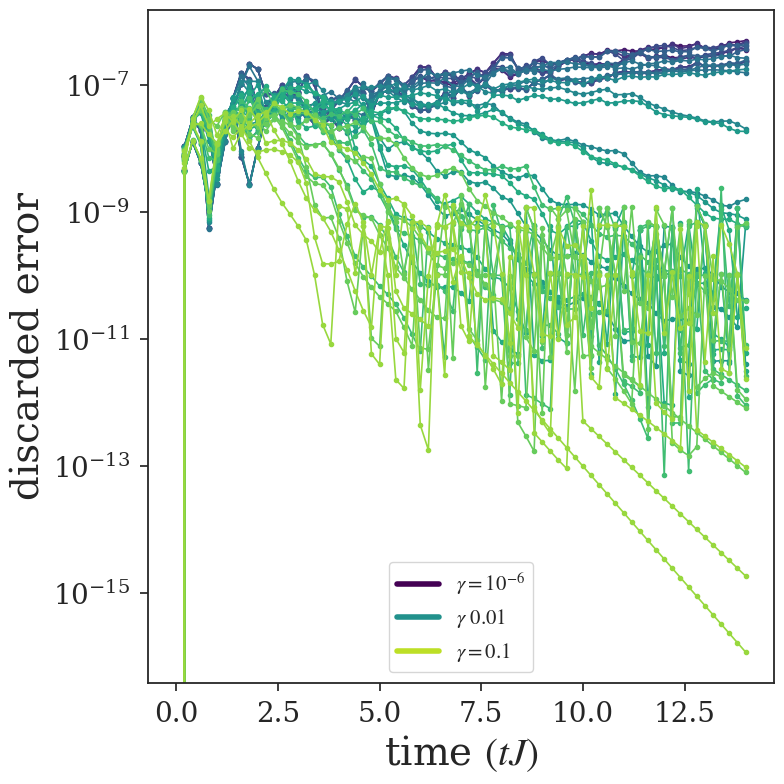

In [26]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    for scale in scale_list:
        if gamma < 0.1:
               axes = ax.plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),trr_in[f"gamma={gamma}_scale={scale}"], 
                    color = c[i], marker="o", ms=3,label=fr"$\gamma={gamma}, \alpha={scale}$", )

ax.set_yscale('log')
ax.set_xlabel(r"time $(tJ)$")
ax.set_ylabel(r"discarded error")
cmap = plt.cm.viridis             
custom_lines = [Line2D([0], [0], color=cmap(0.), lw=4),
                Line2D([0], [0], color=cmap(.5), lw=4),
                Line2D([0], [0], color=cmap(0.9), lw=4)]                

ax.legend(custom_lines, [r"$\gamma=10^{-6}$", r"$\gamma~0.01$", r"$\gamma=0.1$"], fontsize=15)

plt.colormaps.get("viridis", 10)
plt.tight_layout( )
plt.savefig("discarded_error.pdf")

In [27]:
#fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
color_cycle = plt.rcParams['axes.prop_cycle']()


12
4 3


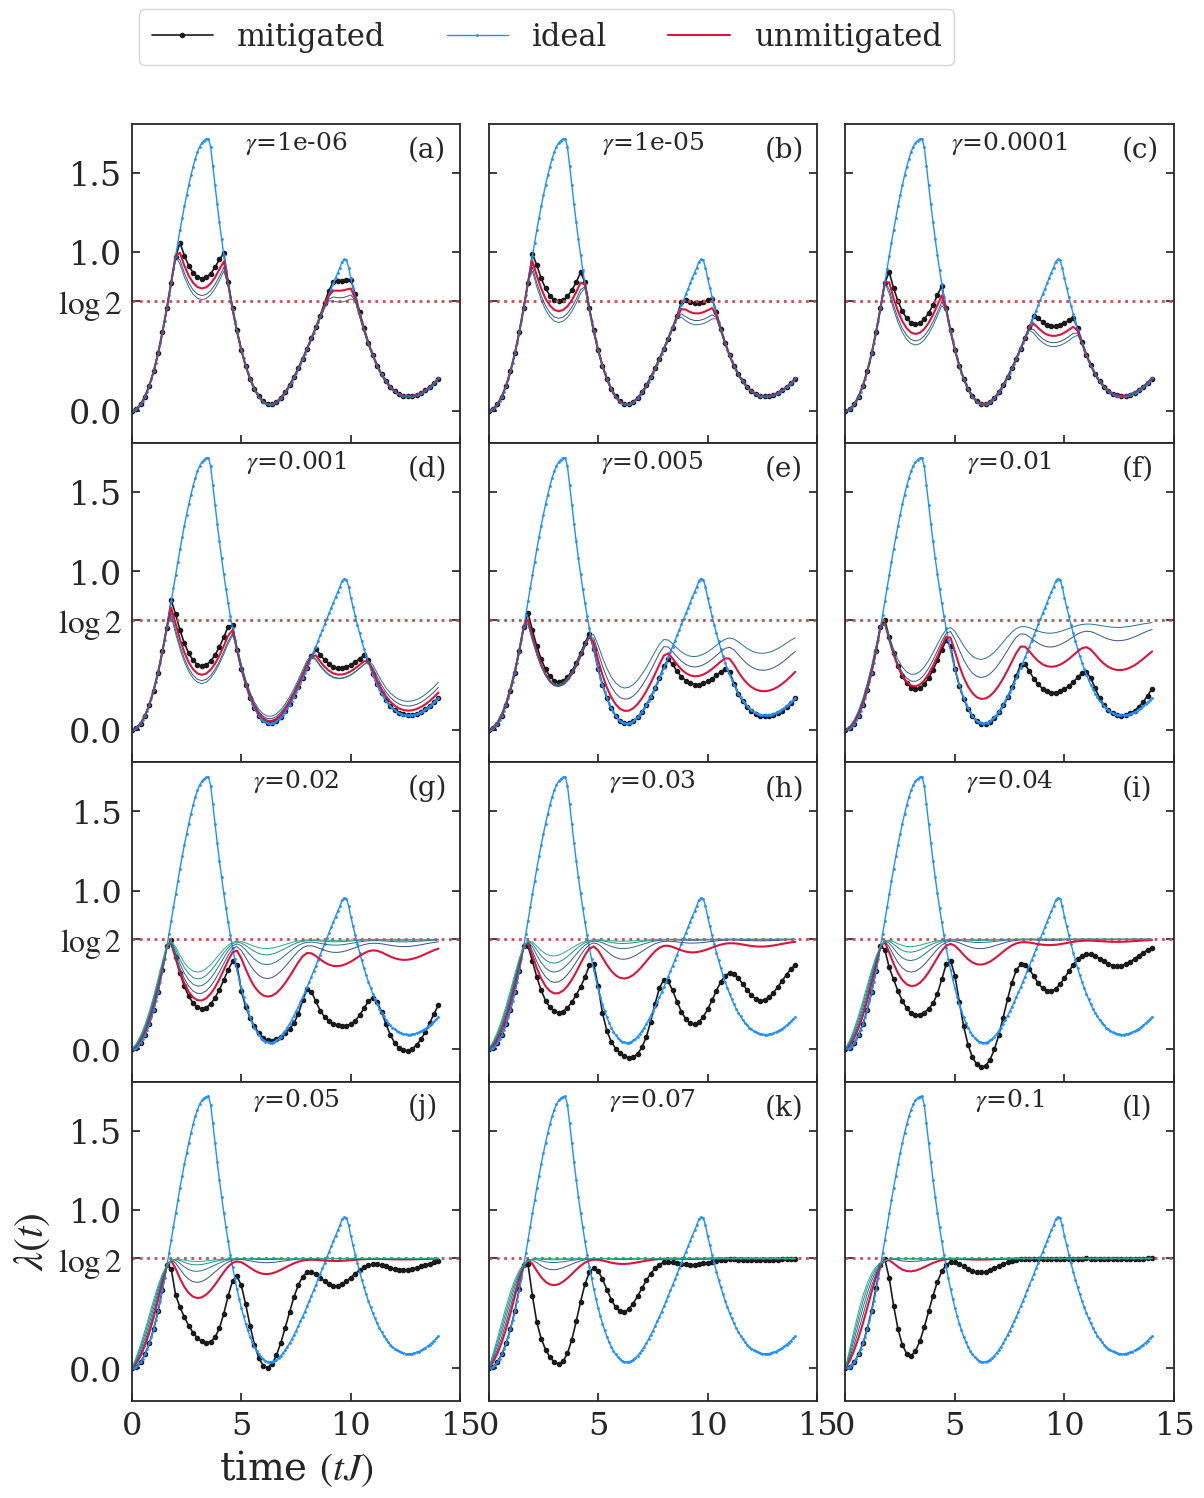

In [28]:
import seaborn as sns
from mpl_toolkits import axisartist
sns.set_theme(style="ticks",)

figure_styling()
data = {}
scale_list = [1.0, 1.5, 2.0, 2.5, 3.0]
gamma_list = [1e-6, 1e-5, 0.0001, 0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1]
print(len(gamma_list))
nrows = 4
ncols = int(len(gamma_list)/nrows)+1
ncols = 3
print(nrows, ncols)

#plt.style.use('classic')

N=32

text="abcdefghijklmnopqrstuvwxyz"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,14), sharey=True, sharex=True, constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            line_rich = ax[m][n].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.array(yout_richadson_ratef[f"{gamma}"]), marker="o", ms=3, color = "k",label="mitigated" )
            #line_rich = ax[m][n].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.array(yout_richadson_Lambda[f"{gamma}"]), marker="o", ms=4, color = "orange",label="exp" )

            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
            #line_nonoise = ax[m][n].plot(ts0, data_czz, lw = 1, color = '#004C99',label="ideal (no-noise)")
            line_nonoise = ax[m][n].plot(2*0.5*np.array(ts0), np.array(data_ratef), marker='o',ms=1,lw = 1., color = '#1E90FF',ls="-", label=r"ideal")
            #line_nonoise = ax[m][n].plot(2*0.5*np.array(ts0), np.exp(-N*np.array(data_ratef)), marker='o',ms=1,lw = 1., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")

            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            ax[m][n].tick_params(axis='both', direction="in", which='major', labelsize=23)
            ax[m][n].tick_params(axis='both', which='minor', labelsize=20)
            tex = text[i]
            ax[m][n].hlines(y=np.log(2), xmin=0, xmax=15.1, linewidth=2,ls=":", color='r')
            #ax[m][n].vlines(x=2*np.pi, ymin=-0.1, ymax=1., linewidth=2,ls=":", color='r')
            #ax[m][n].vlines(x=4*np.pi, ymin=-0.1, ymax=1., linewidth=2,ls=":", color='r')
            ax[m][n].text(12.6, 1.6, "("+tex + ")", fontsize=20)
            g=False
        #line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        if scale  ==1:
            line = ax[m][n].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color='#DC143C', lw=1.5,marker = "", ms=2, label=fr"unmitigated")
        else: 
            line = ax[m][n].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=0.71)
        #line = ax[m][n].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.exp(-N*np.array(ratef_in[f"gamma={gamma}_scale={scale}"])), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")

        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(czz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], ls="-", marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].set_title(fr"$\gamma$={gamma}", fontsize=18,  y=1.0, pad=-18)
        ax[m][n].set_xlim(-0.,15.)
        #ax[m][n].set_ylim(-0.05,0.5)
        if n!=0:
            pass
            #ax[m][n].axes.yaxis.set_visible(False)
            #ax[m][n].axes.yaxis.set_ticklabels([])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False,labelleft=True )
        if m != 2:
            pass
            
            start, end = ax[m][n].get_xlim()
            #ax[m][n].xaxis.set_ticks(np.arange(start, end, 3), size=22)
            ax[m][n].set_yticks([0.0, np.log(2), 1.0, 1.5])
            ax[m][n].set_yticklabels([0.0, r"$\log2$", 1.0, 1.5], size=24)
            #ax[m][n].axes.xaxis.set_visible(False)
            #ax[m][n].axes.xaxis.set_ticklabels([0.0, 5, 10, 14])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False, labelleft=True)
    #ax[m][n].tick_params(labeltop=True, labelright=True)
    ax[m][n].tick_params(which='both', bottom=True, right=True, top=False)#, labelbottom=True) 
    #ax[m][n].axes.xaxis.set_ticklabels(np.arange(0,8,2))
            #pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
ax[3][0].set_xlabel(fr"time $(tJ)$", fontsize=28)
#ax[2][0].set_ylabel(r"$\langle \sigma^z_{\frac{L}{2}} \sigma^z_{\frac{L}{2}+1}\rangle(\alpha t)$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t) = -\frac{1}{N}\log(|\langle \psi_0| e^{-i\mathcal{H}t} |\psi_0 \rangle|^2)$", fontsize=24)
ax[3][0].set_ylabel(r"$\lambda(t)$", fontsize=30)
lines, labels = ax[2][0].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.11,0.08,1.5,1), shadow=False, ncol=4,fontsize=22,frameon=True)


ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"fig1_plot_depolarizing_nonintegrable_lambda_Jxx0.1_{L}_chi_{chi_max}.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')

8
4 2


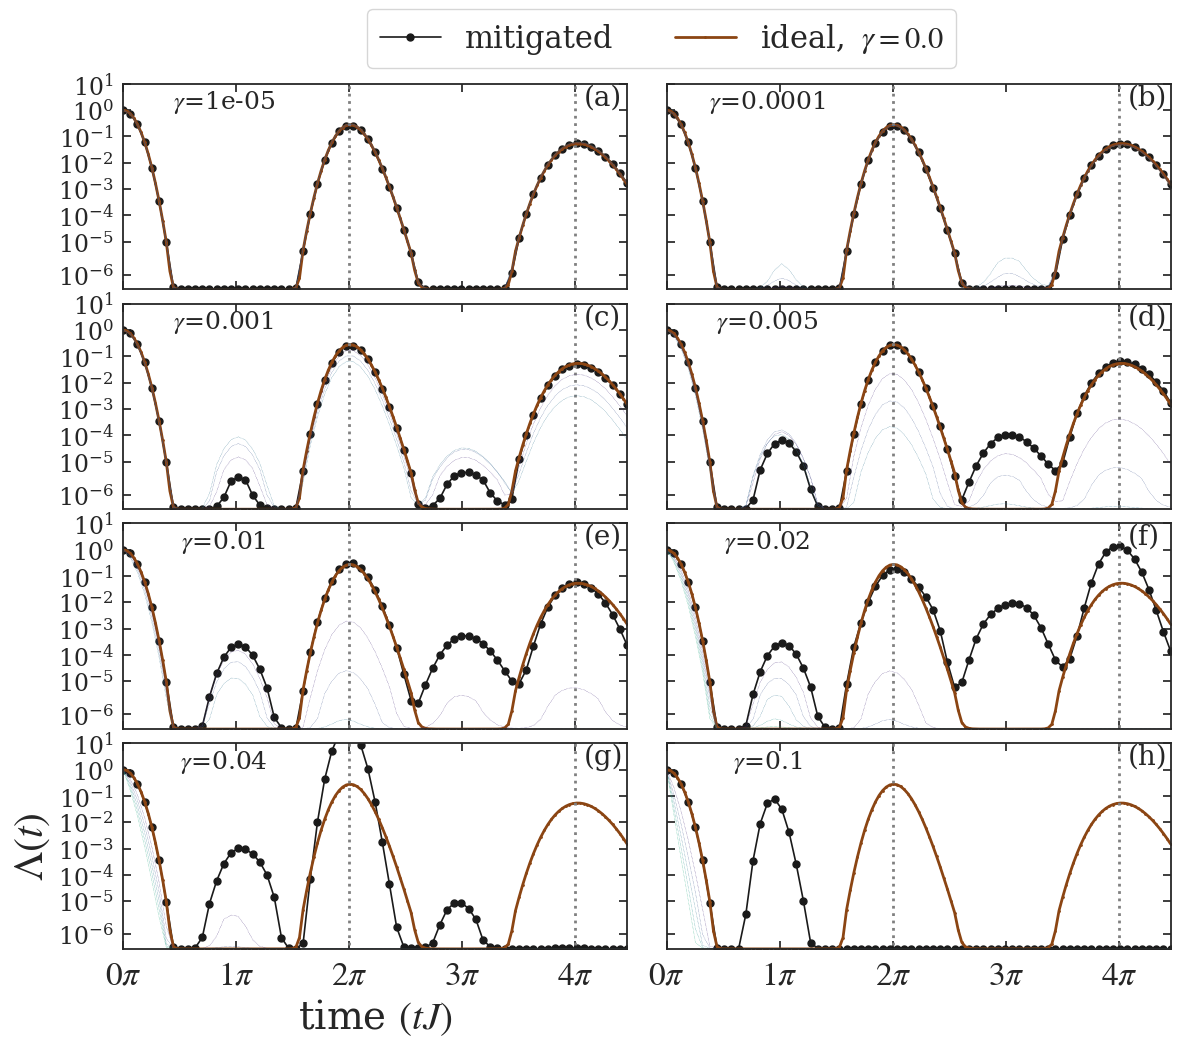

In [29]:
data = {}
scale_list = [1.0, 1.5, 2.0, 2.5, 3.0]
gamma_list = [1e-5, 0.0001, 0.001, 0.005, 0.01, 0.02,  0.04, 0.1]
print(len(gamma_list))
nrows = 4
ncols = int(len(gamma_list)/nrows)+1
ncols = 2
print(nrows, ncols)

#plt.style.use('classic')

N=32

text="abcdefghijklmnopqrstuvwxyz"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,10), sharey=True, sharex=True, constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            #line_rich = ax[m][n].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.array(yout_richadson_Lambda[f"{gamma}"]), marker="o", ms=3, color = "k",label="mitigated" )
            line_rich = ax[m][n].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.exp(-N*np.array(yout_richadson_ratef[f"{gamma}"])), marker="o", ms=5, color = "k",label="mitigated" )

            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
            #line_nonoise = ax[m][n].plot(ts0, data_czz, lw = 1, color = '#004C99',label="ideal (no-noise)")
            #line_nonoise = ax[m][n].plot(2*0.5*np.array(ts0), np.array(data_ratef), marker='o',ms=1,lw = 1., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")
            line_nonoise = ax[m][n].plot(2*0.5*np.array(ts0), np.exp(-N*np.array(data_ratef)), marker='o',ms=1,lw = 2., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")

            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            ax[m][n].tick_params(axis='both', direction="in", which='major', labelsize=17)
            ax[m][n].tick_params(axis='both', which='minor', labelsize=17)
            tex = text[i]
            #ax[m][n].hlines(y=np.log(2), xmin=0, xmax=15.1, linewidth=2,ls=":", color='r')
            ax[m][n].vlines(x=2*np.pi, ymin=-0.1, ymax=10., linewidth=2,ls=":", color='gray')
            ax[m][n].vlines(x=4*np.pi, ymin=-0.1, ymax=10., linewidth=2,ls=":", color='gray')
            ax[m][n].text(12.8, 1.6, "("+tex + ")", fontsize=20)
            
            
            g=False
        #line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        #line = ax[m][n].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        line = ax[m][n].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(Lambda_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=.35, ls=":", marker = "", ms=1)#, label=fr"$\alpha$={scale}")

        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(czz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], ls="-", marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].set_title(fr"$\gamma$={gamma}", fontsize=18, x=0.2, y=1.0, pad=-18)
        ax[m][n].set_xlim(-0.,14.)
        ax[m][n].set_yscale('symlog', linthresh=2e-6)
        ax[m][n].set_ylim(1e-9,10)
        if n!=0:
            pass
            #ax[m][n].axes.yaxis.set_visible(False)
            #ax[m][n].axes.yaxis.set_ticklabels([])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False,labelleft=True )
        if m != 2:
            pass
            
            start, end = ax[m][n].get_xlim()
            #ax[m][n].xaxis.set_ticks(np.arange(start, end, 3), size=22)
            #ax[m][n].set_xticks([0, 3, 6.28, 9, 12.56])
            #ax[m][n].set_xticklabels([0, 3, r"$2\pi$", 9, r"$4\pi$"]) 
            ax[m][n].xaxis.set_major_formatter(plt.FormatStrFormatter('%g $\pi$'))
            #ax[m][n].xaxis.set_major_locator(plt.MultipleLocator(2*np.pi))
            ax[m][n].set_xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
            ax[m][n].set_xticklabels([r"$0\pi$", r"$1\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"], size=24)
            
            #ax[m][n].axes.xaxis.set_visible(False)
            #ax[m][n].axes.xaxis.set_ticklabels([0.0, 5, 10, 14])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False, labelleft=True)
    #ax[m][n].tick_params(labeltop=True, labelright=True)
    ax[m][n].tick_params(which='both', bottom=True, right=True, top=True)#, labelbottom=True) 
    #ax[m][n].axes.xaxis.set_ticklabels(np.arange(0,8,2))
            #pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
ax[3][0].set_xlabel(fr"time $(tJ)$", fontsize=28)
#ax[2][0].set_ylabel(r"$\langle \sigma^z_{\frac{L}{2}} \sigma^z_{\frac{L}{2}+1}\rangle(\alpha t)$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t) = -\frac{1}{N}\log(|\langle \psi_0| e^{-i\mathcal{H}t} |\psi_0 \rangle|^2)$", fontsize=24)
ax[3][0].set_ylabel(r"$\Lambda(t)$", fontsize=30)
lines, labels = ax[2][1].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.3,0.061,1.5,1), shadow=False, ncol=4,fontsize=22,frameon=True)


ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"fig5_plot_depolarizing_nonintegrable_Lambda_Jxx0.1_{L}_chi_{chi_max}.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')

4
4 2


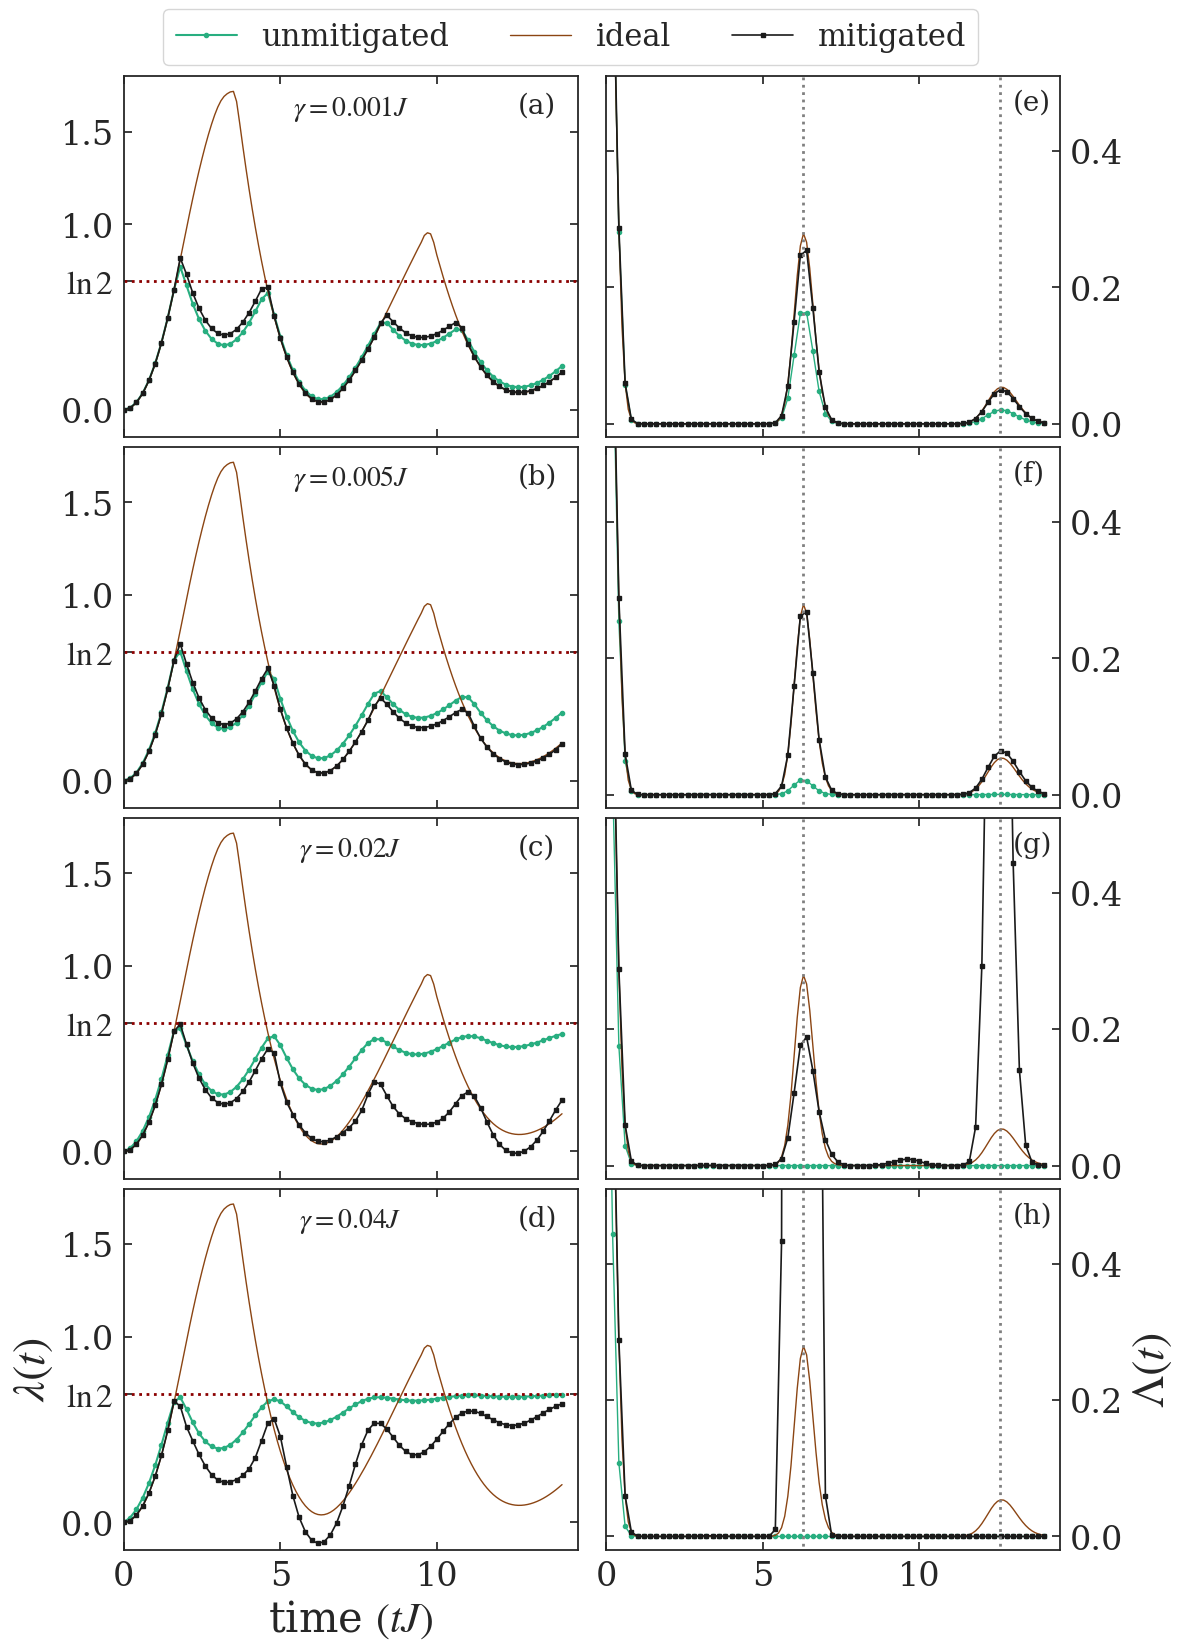

In [32]:
figure_styling()
data = {}
scale_list = [1.0, 1.5, 2.0, 2.5, 3.0]
gamma_list = [0.001, 0.005, 0.02, 0.04]
print(len(gamma_list))
nrows = 4
ncols = int(len(gamma_list)/nrows)+1
ncols = 2
print(nrows, ncols)

#plt.style.use('classic')

N=32

text="abcdefghijklmnopqrstuvwxyz"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,16), sharey=False, sharex=True, constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    g = True 
    m = i#np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        
        if scale ==1:
            line = ax[m][0].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[4], lw=1.5,marker = "o", ms=3, label=fr"unmitigated")
            line_L = ax[m][1].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.exp(-N*np.array(ratef_in[f"gamma={gamma}_scale={scale}"])), color=colors[4], lw=1., marker = "o", ms=3)
            #line = ax[m][0].plot(np.array(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=0.71)
        if g:

            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
            #line_nonoise = ax[m][n].plot(ts0, data_czz, lw = 1, color = '#004C99',label="ideal (no-noise)")
            line_nonoise = ax[m][0].plot(2*0.5*np.array(ts0), np.array(data_ratef), marker='',ms=3,fillstyle="none", lw = 1., color = '#8B4513',ls="-", label=r"ideal")
            line_nonoise_L = ax[m][1].plot(2*0.5*np.array(ts0), np.exp(-N*np.array(data_ratef)), marker='',fillstyle="none",ms=3,lw = 1., color = '#8B4513',ls="-")
            #line_nonoise = ax[m][n].plot(2*0.5*np.array(ts0), np.exp(-N*np.array(data_ratef)), marker='o',ms=1,lw = 1., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")

            
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            line_rich = ax[m][0].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.array(yout_richadson_ratef[f"{gamma}"]), marker="s", ms=3, color = "k",label="mitigated" )
            line_rich_L = ax[m][1].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.exp(-N*np.array(yout_richadson_ratef[f"{gamma}"])), marker="s", ms=3, color = "k" )
            #line_rich = ax[m][n].plot(2*0.5*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),np.array(yout_richadson_Lambda[f"{gamma}"]), marker="o", ms=4, color = "orange",label="exp" )

            
            
            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")

            ax[m][0].tick_params(axis='both', direction="in", which='major', labelsize=23)
            ax[m][0].tick_params(axis='both', which='minor', labelsize=20)
            tex = text[i]
            tex1 = text[i+4]
            ax[m][0].hlines(y=np.log(2), xmin=0, xmax=15.1, linewidth=2,ls=":", color='#8B0000')
            ax[m][1].vlines(x=2*np.pi, ymin=-0.1, ymax=1., linewidth=2,ls=":", color='gray')
            ax[m][1].vlines(x=4*np.pi, ymin=-0.1, ymax=1., linewidth=2,ls=":", color='gray')
            ax[m][0].text(12.6, 1.6, "("+tex + ")", fontsize=20)
            ax[m][1].text(13., .46, "("+tex1 + ")", fontsize=20)
            g=False
            


            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(czz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], ls="-", marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][1].set_yscale('symlog', linthresh=2e-4)
        ax[m][1].yaxis.tick_right()
        ax[m][0].tick_params(axis='both', direction="in", which='both', bottom=True, left=True, right=True, top=True, labelsize=24)
        ax[m][1].tick_params(axis='both', direction="in", which='both', bottom=True, left=True, right=True, top=True, labelsize=24)
        ax[m][0].set_title(fr"$\gamma={gamma}J$", fontsize=20,  y=1.0, pad=-28)
        #ax[m][1].set_title(fr"$\gamma$={gamma}", fontsize=18, x=0.2, y=1.0, pad=-28)
        ax[m][0].set_xlim(-0.,14.5)
        ax[m][0].set_ylim(-0.15,1.8)
        ax[m][1].set_ylim(-0.02,0.51)

            
        start, end = ax[m][0].get_xlim()
        #ax[m][0].xaxis.set_ticks(np.arange(start, end, 3), size=28)
        ax[m][0].set_yticks([0.0, np.log(2), 1.0, 1.5])
        ax[m][0].set_yticklabels([0.0, r"$\ln2$", 1.0, 1.5], size=24)

ax[3][0].set_xlabel(fr"time $(tJ)$", fontsize=30)

ax[3][0].set_ylabel(r"$\lambda(t)$", fontsize=33)
ax[3][1].set_ylabel(r"$\Lambda(t)$", fontsize=33)
ax[3,1].yaxis.set_label_position("right")
lines, labels = ax[2][0].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.13,0.04,1.5,1), shadow=False, ncol=4,fontsize=22,frameon=True)


#ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"fig2_plot_depolarizing_nonintegrable_lambda_Lambda_Jxx0.1_{L}_chi_{chi_max}.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')

8
4 2


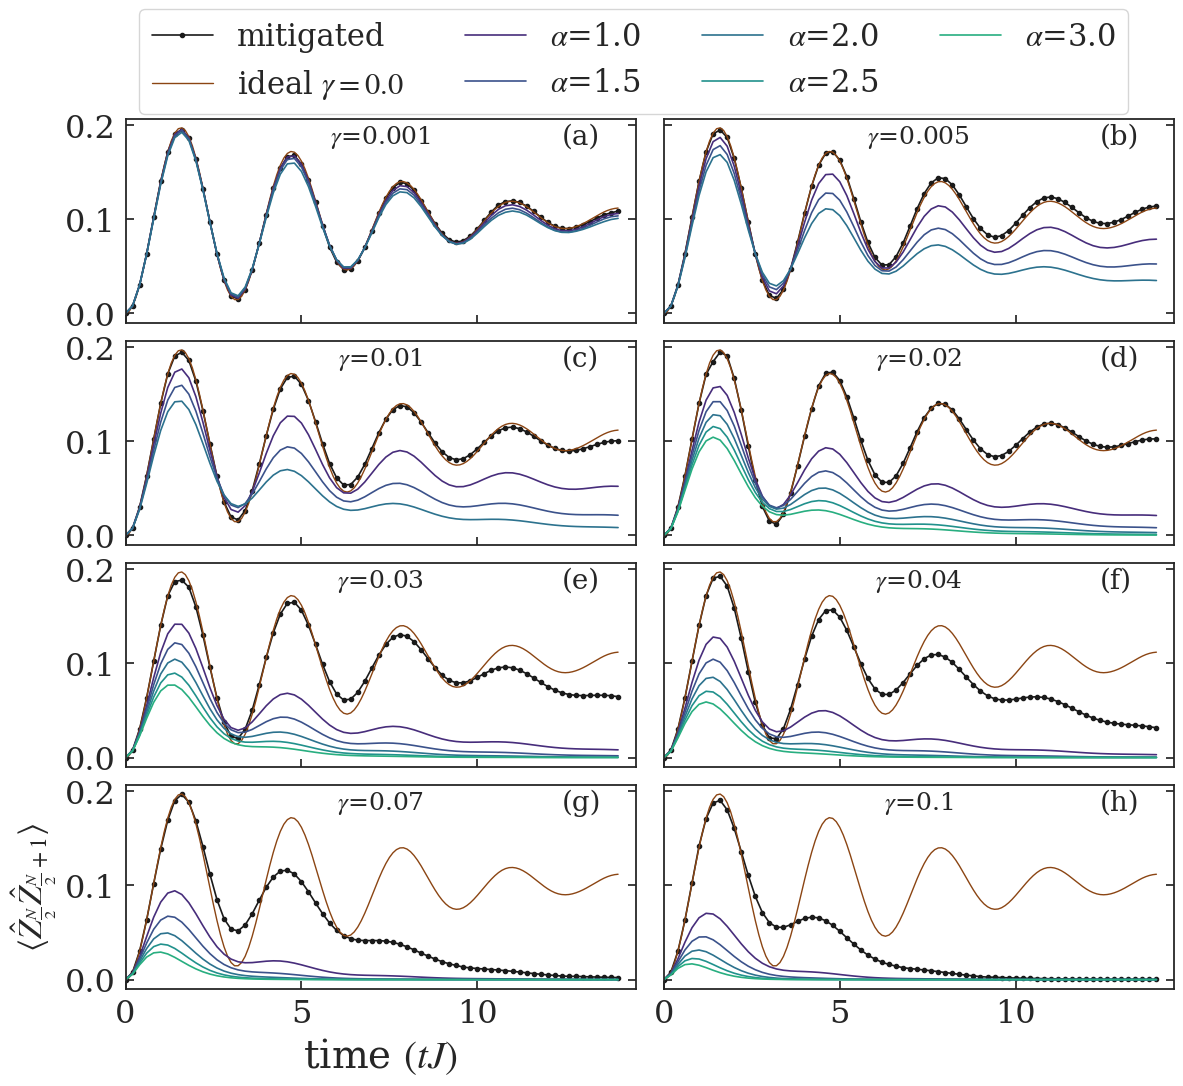

In [34]:
figure_styling()
data = {}
scale_list = [1.0, 2.0, 3.0, 4.0]
gamma_list = [0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.07, 0.1]
print(len(gamma_list))
nrows = 4
ncols = int(len(gamma_list)/nrows)+1
ncols = 2
print(nrows, ncols)

#plt.style.use('classic')



text="abcdefghijklmnopqrstuvwxyzabcdefghijklmnopqrstuvwxyz"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,10), sharey=True, sharex=True, constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="o", ms=3, color = "k",label="mitigated" )
            #line_rich = ax[m][n].plot(1*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_ratef[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
            line_nonoise = ax[m][n].plot(ts0, data_czz, lw = 1, color = '#8B4513',label="ideal $\gamma=0.0$")
            #line_nonoise = ax[m][n].plot(1*np.array(ts0), data_ratef, marker='o',ms=1,lw = 1., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")
            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            ax[m][n].tick_params(axis='both', direction="in", which='major', labelsize=23)
            ax[m][n].tick_params(axis='both', which='minor', labelsize=20)
            tex = text[i]
            #ax[m][n].hlines(y=np.log(2), xmin=0, xmax=15.1, linewidth=2,ls=":", color='r')
            ax[m][n].text(12.4, 0.18, "("+tex + ")", fontsize=20)
            g=False
        #line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        #line = ax[m][n].plot(np.array(1*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(czz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], ls="-", marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].set_title(fr"$\gamma$={gamma}", fontsize=18,  y=1.0, pad=-18)
        ax[m][n].set_xlim(0.,14.5)
        if n!=0:
            pass
            #ax[m][n].axes.yaxis.set_visible(False)
            #ax[m][n].axes.yaxis.set_ticklabels([])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False,labelleft=True )
        if m != 2:
            pass
            
            start, end = ax[m][n].get_xlim()
            #ax[m][n].xaxis.set_ticks(np.arange(start, end, 3), size=22)
            #ax[m][n].axes.xaxis.set_visible(False)
            #ax[m][n].axes.xaxis.set_ticklabels([0.0, 5, 10, 14])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False, labelleft=True)
    #ax[m][n].tick_params(labeltop=True, labelright=True)
    ax[m][n].tick_params(which='both', bottom=True, right=True, top=False)#, labelbottom=True) 
    #ax[m][n].axes.xaxis.set_ticklabels(np.arange(0,8,2))
            #pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
ax[3][0].set_xlabel(fr"time $(tJ)$", fontsize=28)
ax[3][0].set_ylabel(r"$\langle \hat{Z}_{\frac{N}{2}} \hat{Z}_{\frac{N}{2}+1}\rangle$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t) = -\frac{1}{N}\log(|\langle \psi_0| e^{-i\mathcal{H}t} |\psi_0 \rangle|^2)$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t)$", fontsize=30)
lines, labels = ax[3][0].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.11,0.1,1.5,1), shadow=False, ncol=4,fontsize=22,frameon=True)


ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"fig2_plot_depolarizing_nonintegrable_correlation_Jxx0.1_{L}_chi_{chi_max}.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')

4
2 2
4 (0.157851, 0.683765, 0.501686)
4 (0.157851, 0.683765, 0.501686)
4 (0.157851, 0.683765, 0.501686)
4 (0.157851, 0.683765, 0.501686)


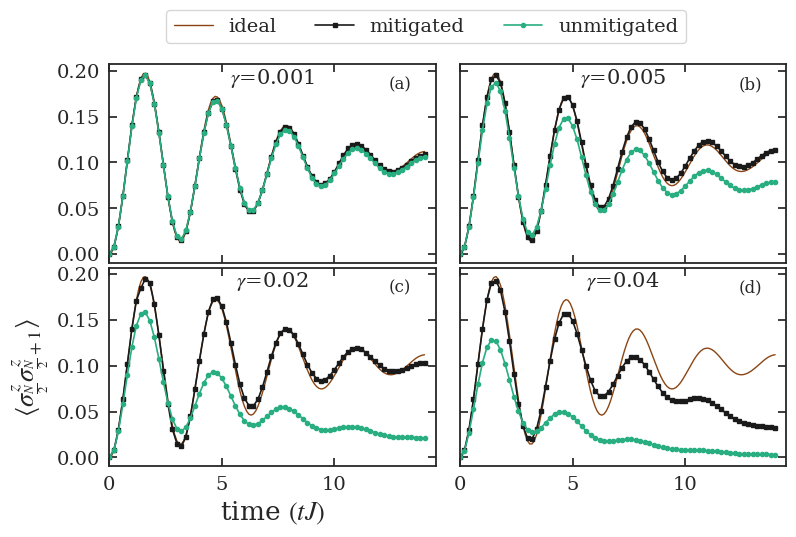

In [37]:
figure_styling()
data = {}
scale_list = [1.0, 2.0, 3.0, 4.0]
gamma_list = [0.001, 0.005,  0.02,  0.04]
print(len(gamma_list))
nrows = 2
ncols = int(len(gamma_list)/nrows)+1
ncols = 2
print(nrows, ncols)

#plt.style.use('classic')



text="abcdefghijklmnopqrstuvwxyzabcdefghijklmnopqrstuvwxyz"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8,5), sharey=True, sharex=True, constrained_layout=False)
m=0
plt_idx=list(itertools.product(*[[0,1]]*2))

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    g = True 
    m = np.floor_divide(i,ncols)
    n = 0#np.mod(i,ncols)
    #print(m,n)
    m = plt_idx[i][0]
    n = plt_idx[i][1]
    ax = axs[m,n]
    if g:
            line_nonoise = ax.plot(ts0, data_czz, marker="",ms=1,lw = 1, color = '#8B4513',label="ideal")
            np.savetxt(f"czz_ideal_{N}.txt",data_czz  )
            np.savetxt(f"ts_ideal_{N}.txt",ts0  )
            
            #line_nonoise = ax[m][n].plot(1*np.array(ts0), data_ratef, marker='o',ms=1,lw = 1., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mx[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            line_rich = ax.plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="s", ms=3, color = "k",label="mitigated" )
            np.savetxt(f"czz_rich_mitigated_{N}_{gamma}.txt",yout_richadson_czz[f"{gamma}"]  )
            np.savetxt(f"tss_{N}_{gamma}.txt",  np.array(tss[f"ts_gamma{gamma}_scale{scale}"]) )
            #line_rich = ax[m][n].plot(1*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_ratef[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            #line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")

            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")
            ax.set_title(fr"$\gamma$={gamma}")
            ax.tick_params(axis='both', direction="in", which='major', labelsize=12)
            ax.tick_params(axis='both', which='minor', labelsize=12)
            tex = text[i]
            #ax[m][n].hlines(y=np.log(2), xmin=0, xmax=15.1, linewidth=2,ls=":", color='r')
            ax.text(12.4, 0.18, "("+tex + ")", fontsize=12)
            g=False
    #line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
    #line = ax[m][n].plot(np.array(1*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
    #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
    scale= 1.0
    ax.plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(czz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], ls="-", marker = "o", ms=3, label=fr"unmitigated")
    np.savetxt(f"czz_in_{N}_{gamma}_{scale}.txt",np.array(czz_in[f"gamma={gamma}_scale={scale}"])  )
    
    print(j, colors[j])
    ax.set_title(fr"$\gamma$={gamma}", fontsize=15,  y=1.0, pad=-14)
    ax.set_xlim(0.,14.5)

    if m != 2:
        pass

        start, end = ax.get_xlim()
        #ax.xaxis.set_ticks(np.arange(start, end, 3), size=14)
        #ax[m][n].axes.xaxis.set_visible(False)
        #ax[m][n].axes.xaxis.set_ticklabels([0.0, 5, 10, 14])
        #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False, labelleft=True)
        #ax[m][n].tick_params(labeltop=True, labelright=True)
    ax.tick_params(which='both', bottom=True, right=True, top=True, labelsize=14)#, labelbottom=True) 
    #ax[m][n].axes.xaxis.set_ticklabels(np.arange(0,8,2))
            #pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
axs[1,0].set_xlabel(fr"time $(tJ)$", fontsize=19)
axs[1,0].set_ylabel(r"$\langle \sigma^{z}_{\frac{N}{2}} \sigma^{z}_{\frac{N}{2}+1}\rangle$", fontsize=19)
#ax[2][0].set_ylabel(r"$\lambda(t) = -\frac{1}{N}\log(|\langle \psi_0| e^{-i\mathcal{H}t} |\psi_0 \rangle|^2)$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t)$", fontsize=30)
lines, labels = ax.get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.19,0.09,0.8,1), shadow=False, ncol=3,fontsize=14,frameon=True)


axs = trim_axs(axs, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"fig2_plot_grid_depolarizing_nonintegrable_correlation_reduced__Jxx0.1_{L}_chi_{chi_max}.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')

In [38]:
len(ts0[::2]), len(tss[f"ts_gamma{gamma}_scale{scale}"])

(71, 71)

In [39]:
gamma_list = [1e-6, 1e-5, 0.001, 0.005, 0.01,  0.02, 0.022, 0.024, 0.026, 0.028, 0.03, 0.032, 0.034, 0.036, 0.038, 0.04, 0.042, 0.044, 0.046, 0.048, 0.05, 0.0525, 0.055, 0.0575, 0.06, 0.0625, 0.065, 0.0675,0.07, 0.0725, 0.075, 0.0775, 0.08, 0.0825, 0.085, 0.0875, 0.09, 0.1]

In [40]:
print(max(data_czz[::2]), min(data_czz[::2]))

0.19719764097142356 -0.0


In [41]:
a =[1,3,6,7,2,1,6,2,4]
wlist = [1]*len(a)
print(a)
def washing(a, length=2):
    
    b=[]
    #for j in range(length):
    #    wlist.insert(0, 0)
    #    a.insert(0, a[0])
    #    a.append(a[-1])
    #    wlist.append(0)
    #print(a, wlist)
    
    for k in range(0,len(a)):
        i= k
        #print(k)
        if k > (len(a)-length):
            #print(a[i-length:])
            b.append(np.average(a[i-length:i]))
        else:
            b.append(np.average(a[i:i+length]))
                     
    return b[:]
b = washing(a,3)
len(b), len(a), b

[1, 3, 6, 7, 2, 1, 6, 2, 4]


(9,
 9,
 [3.3333333333333335,
  5.333333333333333,
  5.0,
  3.3333333333333335,
  3.0,
  3.0,
  4.0,
  3.0,
  3.0])

In [42]:
err_mat = np.zeros((len(gamma_list), len(data_czz[::2])))
dczz = (abs(max(data_czz[::]) - min(data_czz[1::])))
times = tss[f"ts_gamma{0.01}_scale{1.0}"]
#print(len(times))
scale = 1.0
t0_list = []
#tlist = tss[f"ts_gamma{0.01}_scale{scale}"]
for i, gamma in enumerate(gamma_list):
        diff = abs(np.array(yout_richadson_czz[f"{gamma}"])- np.array(data_czz[::2]))/ dczz
        diff = washing(diff, 5)
        err_mat[i, :] = diff
        idx_arry = np.argwhere(np.array(diff) < 0.04)
        idx=idx_arry.shape[0]-2
        #print(gamma, diff)
        t0=times[idx]
        t0_list.append(t0)
        print(gamma, idx_arry.shape[0])

1e-06 71
1e-05 71
0.001 71
0.005 71
0.01 70
0.02 65


KeyError: '0.022'

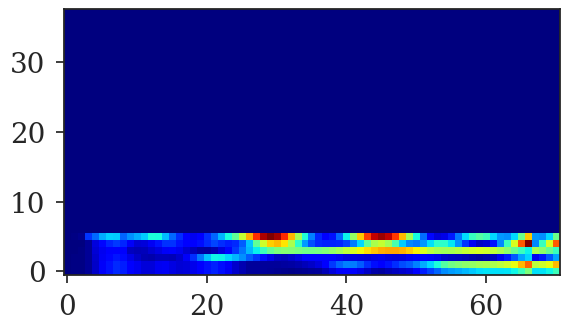

In [43]:
plt.imshow(err_mat, interpolation='none',cmap=plt.cm.jet, origin='lower')  

In [ ]:
#t0_list, gamma_list

/tmp/ipykernel_11019/3377844643.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  new_inferno = cm.get_cmap('inferno', 5)# visualize with the new_inferno colormaps


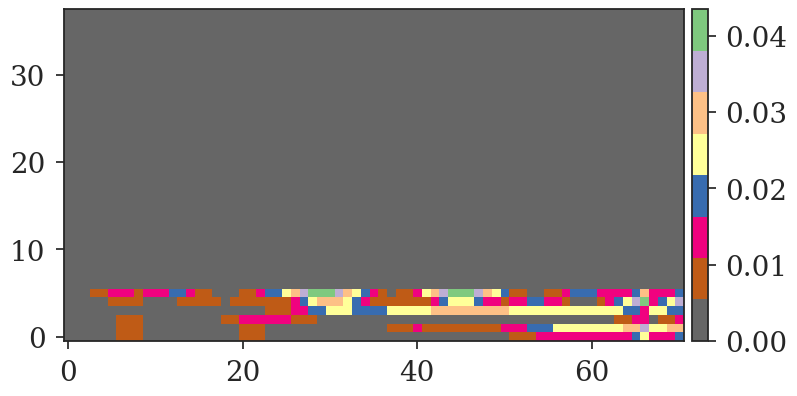

In [44]:
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
new_inferno = cm.get_cmap('inferno', 5)# visualize with the new_inferno colormaps

x_min = min(gamma_list)
x_max= max(gamma_list)
y_min = min(times)
y_max = max(times)

fig, ax = plt.subplots(figsize=(8,8))
X, Y = np.meshgrid(gamma_list[::], times)
extent = [x_min , x_max, y_min , y_max]

im = ax.imshow(err_mat, interpolation='none',cmap=plt.cm.Accent_r, origin='lower')

x_label_list = times
y_label_list = gamma_list





cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
plt.colorbar(im, cax=cax, )

In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


ValueError: x and y must have same first dimension, but have shapes (6,) and (38,)

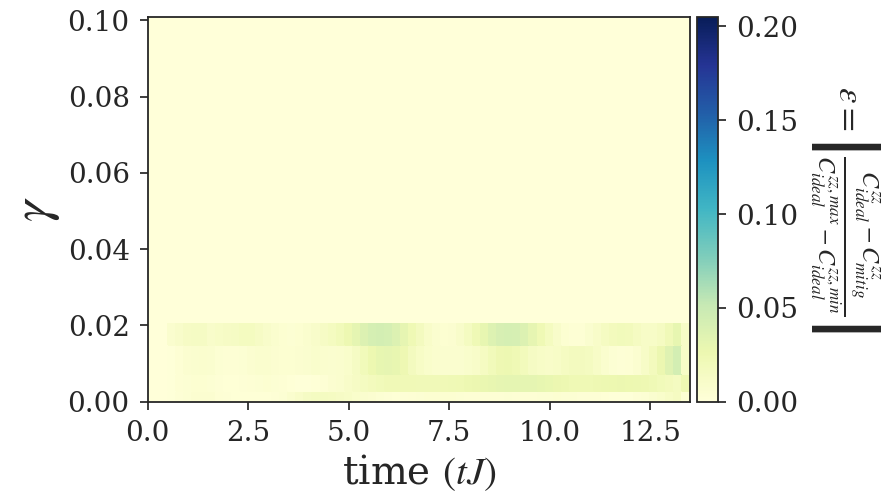

In [46]:
fig, ax = plt.subplots(figsize=(7,5))
vmin,vmax = np.min(err_mat.flatten()), dczz+0.01#np.max(err_mat.flatten())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
#norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0.05, vmax=vmax)
#norm = mpl.colors.LogNorm(vmax=1e-1)
#norm = mpl.colors.SymLogNorm(linthresh=0.1)
mesh = ax.pcolormesh(times, np.array(gamma_list),  err_mat,norm=norm,cmap=plt.cm.YlGnBu ,shading='auto',edgecolors='face',rasterized=True )
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.03,ax.get_position().height])
cbar = plt.colorbar(mesh, cax=cax,  )
#divider = make_axes_locatable(ax)
cbar.ax.set_ylabel(r'$\varepsilon = \left | \frac{C^{zz}_{ideal} - C^{zz}_{mitig}}{C^{zz,max}_{ideal}-C^{zz,min}_{ideal}} \right |$', size=25, labelpad=60,rotation=270, loc="center")
ax.set_ylim(0,0.101)
ax.set_xlim(0,13.5)
ax.set_xlabel(r"time $(tJ)$")
ax.set_ylabel(r"$\gamma$", size=39)
ax.plot(t0_list, gamma_list,marker="o", ms=6,ls=":", lw=3,color="#DC143C")
#plt.tight_layout()
plt.plot()
plt.savefig("phase_diagram_threshold.pdf", bbox_inches='tight')

In [ ]:
plt.plot(t0_list, np.array(gamma_list), marker="o" )

11
4 3


ValueError: labels argument cannot be None when kwargs are passed

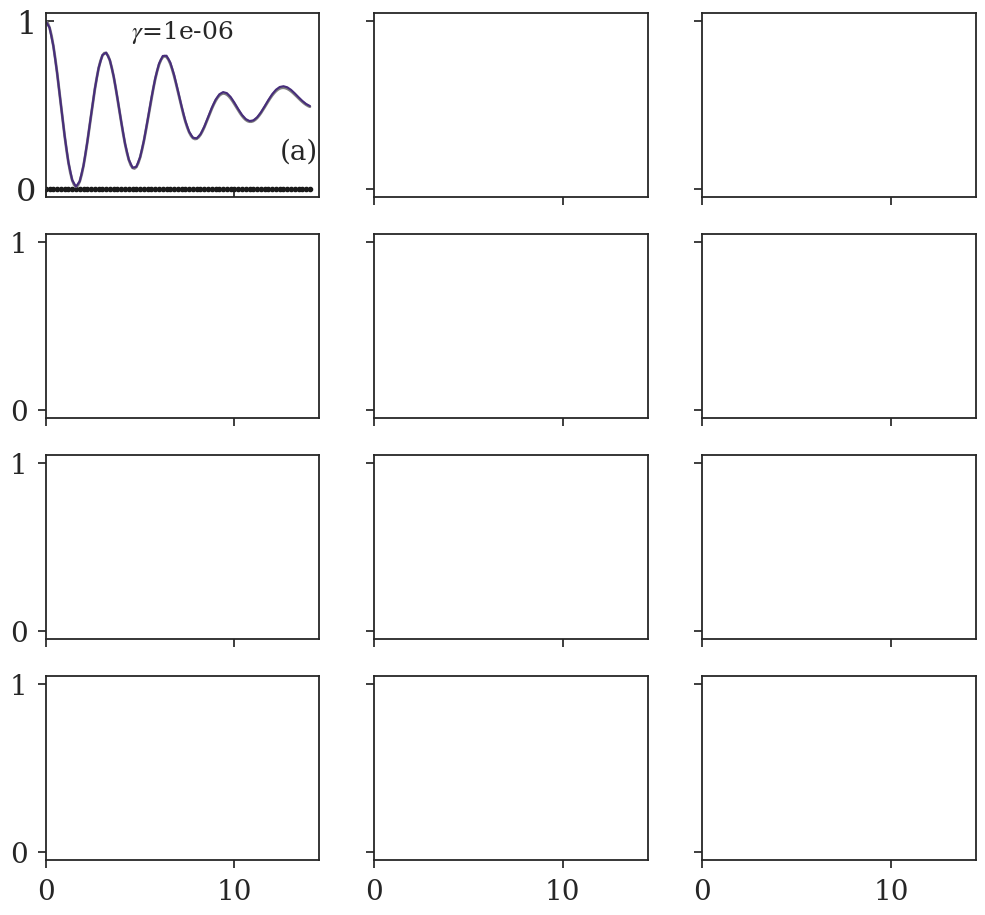

In [47]:
figure_styling()
data = {}
scale_list = [1.0, 2.0, 3.0, 4.0]
gamma_list = [1e-6, 1e-5, 0.001, 0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.07, 0.1]
print(len(gamma_list))
nrows = 4
ncols = int(len(gamma_list)/nrows)+1
ncols = 3
print(nrows, ncols)

#plt.style.use('classic')



text="abcdefghijklmnopqrstuvwxyz"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,11), sharey=True, sharex=True, constrained_layout=False)
m=0

for i, gamma in enumerate(gamma_list):
    scale_list = scale_gamma(gamma)
    g = True 
    m = np.floor_divide(i,ncols)
    n = np.mod(i,ncols)
    #print(m,n)
    
    for j, scale in enumerate(scale_list):

        if g:
            line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"], marker="o", ms=3, color = "k",label="richardson" )
            #line_rich = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_czz[f"{gamma}"], marker="o", ms=3, color = "k",label="mitigated" )
            #line_rich = ax[m][n].plot(1*np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_ratef[f"{gamma}"], marker="o", ms=3, color = "k",label="Richardson" )
            #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]),yout_richadson_mz[f"{gamma}"],marker="o", ms=3, color = "k",label="richardson" )
            line_nonoise = ax[m][n].plot(ts0, data_mx0, lw = 2, color = '#808080',label="ideal (no-noise)")
            #line_nonoise = ax[m][n].plot(ts0, data_czz, lw = 1, color = '#8B4513',label="ideal $\gamma=0.0$")
            #line_nonoise = ax[m][n].plot(1*np.array(ts0), data_ratef, marker='o',ms=1,lw = 1., color = '#8B4513',ls="-", label=r"ideal, $~\gamma=0.0$")
            #ax[m][n].plot(ts0, data_mz0, color="#8A2BE2",label="ideal")
            ax[m][n].set_title(fr"$\gamma$={gamma}")
            ax[m][n].tick_params(axis='both', direction="in", which='major', labelsize=23)
            ax[m][n].tick_params(axis='both', which='minor', labelsize=20)
            tex = text[i]
            #ax[m][n].hlines(y=np.log(2), xmin=0, xmax=15.1, linewidth=2,ls=":", color='r')
            ax[m][n].text(12.4, 0.18, "("+tex + ")", fontsize=20)
            g=False
        line = ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mx_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        #line = ax[m][n].plot(np.array(1*np.array(tss[f"ts_gamma{gamma}_scale{scale}"])), np.array(ratef_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], lw=1.5,marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(mz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], marker = "", ms=1, label=fr"$\alpha$={scale}")
        #ax[m][n].plot(np.array(tss[f"ts_gamma{gamma}_scale{scale}"]), np.array(czz_in[f"gamma={gamma}_scale={scale}"]), color=colors[j], ls="-", marker = "", ms=1, label=fr"$\alpha$={scale}")
        ax[m][n].set_title(fr"$\gamma$={gamma}", fontsize=18,  y=1.0, pad=-18)
        ax[m][n].set_xlim(0.,14.5)
        if n!=0:
            pass
            #ax[m][n].axes.yaxis.set_visible(False)
            #ax[m][n].axes.yaxis.set_ticklabels([])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False,labelleft=True )
        if m != 2:
            pass
            
            start, end = ax[m][n].get_xlim()
            ax[m][n].xaxis.set_ticks(np.arange(start, end, 3), size=22)
            #ax[m][n].axes.xaxis.set_visible(False)
            #ax[m][n].axes.xaxis.set_ticklabels([0.0, 5, 10, 14])
            #ax[m][n].tick_params(which='both', bottom=True, right=True, top=False,labelbottom=False, labelleft=True)
    #ax[m][n].tick_params(labeltop=True, labelright=True)
    ax[m][n].tick_params(which='both', bottom=True, right=True, top=False)#, labelbottom=True) 
    #ax[m][n].axes.xaxis.set_ticklabels(np.arange(0,8,2))
            #pass
#for i in range(6):
#    ax[2][i].set_xticks(range(0,9,2))
#ax[0][0].set_ylim(0.2,0.4)
ax[3][0].set_xlabel(fr"time $(tJ)$", fontsize=28)
ax[3][0].set_ylabel(r"$\langle \hat{Z}_{\frac{L}{2}} \hat{Z}_{\frac{L}{2}+1}\rangle$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t) = -\frac{1}{N}\log(|\langle \psi_0| e^{-i\mathcal{H}t} |\psi_0 \rangle|^2)$", fontsize=24)
#ax[2][0].set_ylabel(r"$\lambda(t)$", fontsize=30)
lines, labels = ax[3][0].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.11,0.1,1.5,1), shadow=False, ncol=4,fontsize=22,frameon=True)


ax = trim_axs(ax, len(gamma_list))

plt.tight_layout(h_pad=0, )
plt.plot()
plt.savefig(f"fig2_plot_depolarizing_nonintegrable_mx_Jxx0.1_{L}_chi_{chi_max}.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')

In [51]:
pathL = Path("/home/younes/Documents/repos/tensor_networks_Hannover/data/data_depolarizing_2nd_nonintegrable_small_noise_valley")

In [52]:

mx_in = {}
mz_in = {}
czz_in = {}
cz1_in = {}
cz2_in={}
trr_in = {}
ratef_in = {}

ts = {}

tmp_data = {}
tss = {}
L_list = [ 12,16, 20, 24, 32, 40, 48, 64]
gamma_list = [0.001, 0.005]
scale = 1.0
Jz=0.5
Jx=0.05
hx=0.05



for L in L_list:
    for i, gamma in enumerate(gamma_list):
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-{Jz}_Jx-{Jx}_hx-{hx}_{L}_{chi_max}'/f'mxs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mx_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off)
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'mzs_scale-{scale}_gamma-{gamma}.pickle', "rb")
        mz_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off)
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'ts_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ts[f"ts_gamma{gamma}_L={L}"] = np.array(cPickle.load(cPickle_off))
        tss[f"ts_gamma{gamma}_L={L}"] = ts[f"ts_gamma{gamma}_L={L}"]/scale
        
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'czz_scale-{scale}_gamma-{gamma}.pickle', "rb")
        czz_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off)
        #print(len(czz_in[f"gamma={gamma}_scale={scale}"]), gamma, scale)
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'czz1_scale-{scale}_gamma-{gamma}.pickle', "rb")
        cz1_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off) 
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'czz2_scale-{scale}_gamma-{gamma}.pickle', "rb")
        cz2_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off)        
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'rate_f_scale-{scale}_gamma-{gamma}.pickle', "rb")
        ratef_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off)     
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'rate_f_scale-{scale}_gamma-{gamma}.pickle', "rb")
        Lambda_in[f"gamma={gamma}_L={L}"] = np.exp(-N*np.array(cPickle.load(cPickle_off)))     
        
        cPickle_off = open(pathL/f'subdata_TFIChain_Jz-0.5_Jx-0.05_hx-0.05_{L}_{chi_max}'/f'trr_err_scale-{scale}_gamma-{gamma}.pickle', "rb")
        trr_in[f"gamma={gamma}_L={L}"] = cPickle.load(cPickle_off)     
        
        

In [53]:

c = sns.color_palette('viridis_r', n_colors=len(L_list))
c
#plt.cm.Accent

[(0.709898, 0.868751, 0.169257),
 (0.430983, 0.808473, 0.346476),
 (0.20803, 0.718701, 0.472873),
 (0.119699, 0.61849, 0.536347),
 (0.147607, 0.511733, 0.557049),
 (0.190631, 0.407061, 0.556089),
 (0.244972, 0.287675, 0.53726),
 (0.281412, 0.155834, 0.469201)]

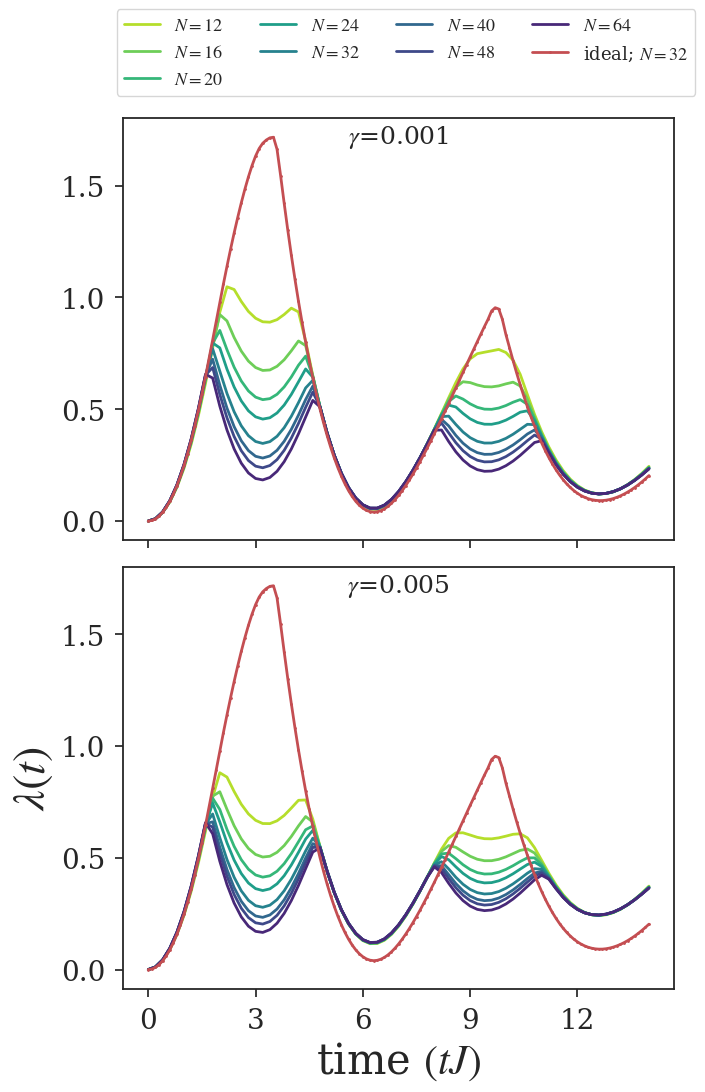

In [75]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(7,10), sharex=True, sharey=True, squeeze=True)
for i, gamma in enumerate(gamma_list):
    for j, L in enumerate(L_list):
        plot = ax[i].plot(tss[f"ts_gamma{gamma}_L={L}"], (np.array(ratef_in[f"gamma={gamma}_L={L}"])), color=c[j], lw=2, label=f"$N={L}$")
        ax[i].set_title(fr"$\gamma$={gamma}", fontsize=18,  y=1.0, pad=-18)
    line_nonoise = ax[i].plot(2*0.5*np.array(ts0), np.array(data_ratef), marker='o',ms=1,lw = 2., color = 'r',ls="-", label=r"ideal; $N=32$")
lines, labels = ax[1].get_legend_handles_labels()
    
#fig.legend(lines, labels, loc = (0.1,0.91), ncol=5,fontsize=12, frameon=False)
leg = fig.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.165,0.1,1.5,1), shadow=False, ncol=4,fontsize=13,frameon=True)

ax[1].set_xticks(np.arange(0,15, 3))
#ax[1].set_xticklabels([r"$0\pi$", r"$\frac{1}{2}\pi$", r"$1\pi$", r"$\frac{3}{2}\pi$", r"$2\pi$", r"$\frac{5}{2}\pi$", r"$3\pi$", r"$\frac{7}{2}\pi$", r"$4\pi$"], size=22)


ax[1].set_xlabel(fr"time $(tJ)$", fontsize=30)

ax[1].set_ylabel(r"$\lambda(t)$", fontsize=33)

plt.tight_layout( )

plt.savefig(f"fig_DQPT_L_dependent.pdf", bbox_extra_artists=(leg,), bbox_inches='tight')
plt.show()

In [ ]:
for gamma in gamma_list:
    for L in L_list:
        plt.plot(tss[f"ts_gamma{gamma}_L={L}"], trr_in[f"gamma={gamma}_L={L}"])